# Wash Trading · Part 1 · v3 — the data generator for Part 2

In v2 a wash wallet *only* ever wash-traded, so the rule "this account never trades normally" would already
detect it perfectly and Part 2's precision/recall could not tell methods apart. v3 adds what makes detection a
real problem (v1 and v2 are frozen):

1. **Camouflage wallets.** The wallet is an ordinary ZI trader (own private values, geometric arrivals, regular
   limit orders) that a wash controller also drives — the "commingling with authentic orders" pattern in
   Sirolly, Ma, Kanoria & Sethi (2026), Example 7. This required replacing upstream `withdraw_all` with
   **order-scoped cancellation**; otherwise the wallet's own ZI arrival would cancel its exposed wash leg.
2. **Several independent wash groups.** `wash_groups=[WashGroup(3), WashGroup(2, gap=5, camouflage=True), ...]`,
   one controller per group. Event starts of different groups never share a timestep (the colliding start is
   deferred one step), so two groups' crossing pairs cannot match each other by accident.
3. **The data schema and batch generation.** Each run is split into `observable/` (the only folder a detector
   may read) and `labels/` (evaluation only); `generate.py` builds a full background × scenario × seed dataset
   in one command.

With a single group and no camouflage, **v3 reproduces v2 trade for trade** (`run_smoke.py`, check B: tape, cash,
event log and LOB all identical).

In [1]:
import os, sys, json

def _find_root(start):
    d = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(d, "marketsim")) and os.path.isdir(os.path.join(d, "capstone codes")):
            return d
        p = os.path.dirname(d)
        if p == d:
            return None
        d = p

ROOT = _find_root(os.getcwd())
assert ROOT, "repo root not found"
for p in (ROOT, os.path.join(ROOT, "capstone codes")):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from washtrade.v3 import WashGroup, WashTradingSimulator
from washtrade.v3 import analysis as A
from washtrade.v3 import scenarios as S
from washtrade.v3.export import load_observable, load_labels, load_meta

pd.set_option("display.width", 180)
DATA = os.path.join(ROOT, "capstone codes", "washtrade", "v3", "data", "ds_v3")
print("dataset:", os.path.relpath(DATA, ROOT), "| exists:", os.path.isdir(DATA))

dataset: capstone codes\washtrade\v3\data\ds_v3 | exists: True


## A. Equivalence with v2 (regression guarantee)

To support camouflage wallets, v3 restates the body of each timestep: it copies the upstream step line for line
and only swaps `withdraw_all` for order-scoped cancellation. For runs without camouflage the two kinds of
cancellation coincide, so v3 must reproduce v2 exactly. One gap = 5 condition is checked here.

In [2]:
from washtrade.v2 import WashTradingSimulator as V2

def tape(sim):
    return [(m.time, m.order.agent_id, m.order.order_id, m.order.order_type, m.order.quantity, m.price)
            for m in sim.markets[0].matched_orders]

S.seed_all(0); a = V2({"ZI": 13, "WashTrader": 3}, sim_time=2000, lam=5e-3, lam_wash=0.05, wash_gap=5, wash_seed=0); a.run()
S.seed_all(0); b = WashTradingSimulator({"ZI": 13, "WashTrader": 3}, sim_time=2000, lam=5e-3, lam_wash=0.05, wash_gap=5, wash_seed=0); b.run()
ev_a = pd.DataFrame(a.controller.event_log)
print("identical tape:         ", tape(a) == tape(b), f"({len(tape(b))} legs)")
print("identical position/cash:", all(a.agents[i].position == b.agents[i].position and a.agents[i].cash == b.agents[i].cash for i in a.agents))
print("identical event log:    ", ev_a.equals(pd.DataFrame(b.controllers[0].event_log)[ev_a.columns]))

identical tape:          True (168 legs)
identical position/cash: True
identical event log:     True


## B. Camouflage wallets

Same seed, `triad` (pure wash wallets) vs `triad_camo` (the wallets are also ZIs). A camouflage wallet's position
is the wash rotation **plus** the inventory it accumulates as a ZI, so it no longer returns exactly to zero every
cycle — which directly weakens the position-closing score used in Part 2.

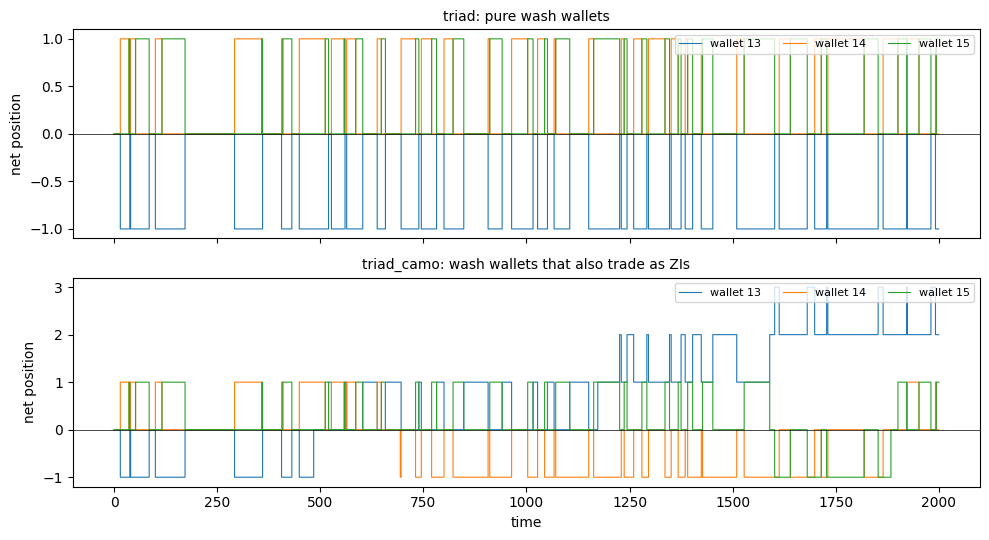

is_wash_leg,ordinary ZI legs,wash legs
agent_id,,
13,3,59
14,1,59
15,2,59


In [3]:
tri = S.run("thin", "triad", 0)
cam = S.run("thin", "triad_camo", 0)

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for ax, sim, name in zip(axes, (tri, cam), ("triad: pure wash wallets", "triad_camo: wash wallets that also trade as ZIs")):
    ts = A.position_timeseries(sim)
    for aid in ts.columns:
        ax.step(ts.index, ts[aid], where="post", lw=0.8, label=f"wallet {aid}")
    ax.axhline(0, color="k", lw=0.5); ax.set_title(name, fontsize=10); ax.set_ylabel("net position")
    ax.legend(fontsize=8, ncol=3, loc="upper right")
axes[-1].set_xlabel("time"); plt.tight_layout(); plt.show()

tl = A.trade_log_df(cam)
per = (tl[tl.agent_id.isin(cam.camouflage_ids)]
         .groupby(["agent_id", "is_wash_leg"]).size().unstack(fill_value=0)
         .rename(columns={False: "ordinary ZI legs", True: "wash legs"}))
per

How strong the camouflage is depends on how active the honest market is. ZIs trade rarely here, so a camouflage
wallet makes far fewer ordinary trades than wash trades. Across 10 seeds, both backgrounds:

In [4]:
rows = []
for bg in ("thin", "thick"):
    for seed in range(10):
        s = A.summarize(S.run(bg, "triad_camo", seed, record_lob=False))
        rows.append(dict(background=bg, seed=seed, wash_legs=s["wash_legs"],
                         ordinary_legs_by_wallets=s["camouflage_legit_legs"],
                         self_trade_rate=s["self_trade_rate"]))
camo = pd.DataFrame(rows)
g = camo.groupby("background")[["wash_legs", "ordinary_legs_by_wallets", "self_trade_rate"]].mean().round(2)
g["ordinary_share_of_wallet_legs"] = (g.ordinary_legs_by_wallets / (g.ordinary_legs_by_wallets + g.wash_legs)).round(3)
g

,wash_legs,ordinary_legs_by_wallets,self_trade_rate,ordinary_share_of_wallet_legs
background,,,,
thick,186.2,17.1,0.96,0.084
thin,187.7,8.0,0.99,0.041


## C. Multiple wash groups

`two_groups` = a triad and a dyad, independent of each other; `hard` = both groups camouflaged with gap = 5.
Each group has its own order_id range (1e9 + group × 1e8), so every wash leg can be attributed to its group;
colliding event starts are deferred one step (`n_deferred`).

--- two_groups


,group_id,n_wallets,wallet_ids,gap,camouflage,n_events,self_trade_rate,intercept_rate,leg_fill_rate,final_net,n_deferred
0,0,3,"[13, 14, 15]",0,False,89,1.000000,0.0,1.000000,0,0
1,1,2,"[16, 17]",0,False,94,0.978723,0.0,0.989362,0,3


--- hard


,group_id,n_wallets,wallet_ids,gap,camouflage,n_events,self_trade_rate,intercept_rate,leg_fill_rate,final_net,n_deferred
0,0,3,"[13, 14, 15]",5,True,73,0.849315,0.082192,0.965753,-5,1
1,1,2,"[16, 17]",5,True,81,0.839506,0.111111,0.925926,-2,9


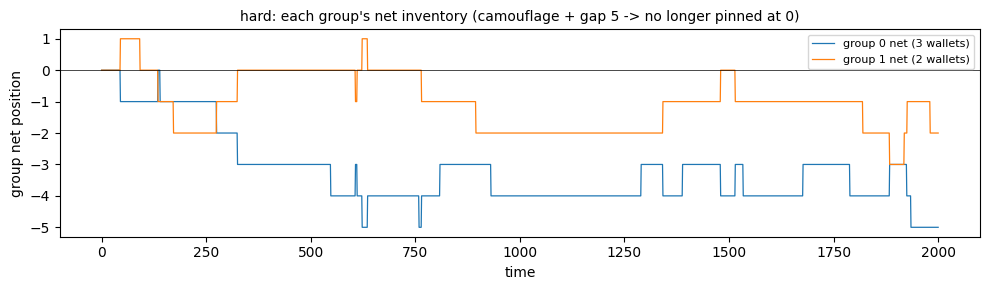

In [5]:
for scen in ("two_groups", "hard"):
    sim = S.run("thin", scen, 0)
    print(f"--- {scen}")
    display(A.group_summary(sim)[["group_id", "n_wallets", "wallet_ids", "gap", "camouflage", "n_events",
                                  "self_trade_rate", "intercept_rate", "leg_fill_rate", "final_net", "n_deferred"]])
hard = sim
fig, ax = plt.subplots(figsize=(10, 3))
for c in hard.controllers:
    ax.plot(A.position_timeseries(hard, c.wallet_ids).sum(axis=1), lw=0.9, label=f"group {c.group_id} net ({len(c.wallet_ids)} wallets)")
ax.axhline(0, color="k", lw=0.5); ax.legend(fontsize=8); ax.set_xlabel("time"); ax.set_ylabel("group net position")
ax.set_title("hard: each group's net inventory (camouflage + gap 5 -> no longer pinned at 0)", fontsize=10)
plt.tight_layout(); plt.show()

## D. The `ds_v3` dataset

`generate.py --name ds_v3 --seeds 10` produces **2 backgrounds × 9 scenarios × 10 seeds = 180 runs**.

| Background | Composition | Note |
|---|---|---|
| thin | 13 ZI, λ = 5e-3 | PyMarketSim Table 3 setting (used throughout v1/v2) |
| thick | 30 ZI, λ = 2e-2 | ~3.5× as many honest trades; wash share roughly halves |

| Scenario | The one thing changed relative to `triad` |
|---|---|
| control | no wash trading (false-positive baseline) |
| triad / dyad | 3-wallet cycle / 2-wallet reciprocal edge |
| triad_gap5 / triad_gap20 | legs 5 / 20 steps apart (interception) |
| triad_camo | wallets also trade as ZIs |
| triad_lowint | wash intensity λ_wash 0.05 → 0.01 |
| two_groups | a triad and a dyad |
| hard | two groups + camouflage + gap 5 |

In [6]:
man = pd.read_csv(os.path.join(DATA, "manifest.csv"))
order = list(S.SCENARIOS)
man["scenario"] = pd.Categorical(man["scenario"], order, ordered=True)
overview = (man.groupby(["background", "scenario"], observed=True)
               .agg(runs=("run_id", "size"), wallets=("n_wallets", "mean"), events=("n_events", "mean"),
                    self_trade=("self_trade_rate", "mean"), intercept=("intercept_rate", "mean"),
                    trade_legs=("total_trade_legs", "mean"), wash_volume_share=("wash_leg_volume_share", "mean"))
               .round(2))
overview

runs  wallets  events  self_trade  intercept  trade_legs  wash_volume_share
background scenario                                                                                 
thick      control         10      0.0     0.0         NaN        NaN       125.8               0.00
           triad           10      3.0    94.3        0.96       0.00       311.6               0.60
           dyad            10      2.0    94.3        0.96       0.00       311.4               0.60
           triad_gap5      10      3.0    75.8        0.82       0.14       269.2               0.53
           triad_gap20     10      3.0    48.7        0.55       0.41       212.4               0.40
           triad_camo      10      3.0    94.3        0.96       0.00       329.2               0.57
           triad_lowint    10      3.0    19.9        0.95       0.00       162.6               0.24
           two_groups      10      5.0   192.5        0.96       0.00       500.6               0.76
           hard            10      5.0   153.7        0.64       0.24       454.0               0.60
thin       control         10      0.0     0.0         NaN        NaN        30.4               0.00
           triad           10      3.0    94.3        0.99       0.00       218.2               0.86
           dyad            10      2.0    94.3        0.99       0.00       218.0               0.86
           triad_gap5      10      3.0    75.8        0.94       0.04       180.0               0.82
           triad_gap20     10      3.0    48.7        0.77       0.19       117.6               0.74
           triad_camo      10      3.0    94.3        0.99       0.00       227.4               0.83
           triad_lowint    10      3.0    19.9        0.98       0.00        71.6               0.55
           two_groups      10      5.0   192.5        0.99       0.00       411.4               0.93
           hard            10      5.0   153.7        0.76       0.13       325.4               0.86

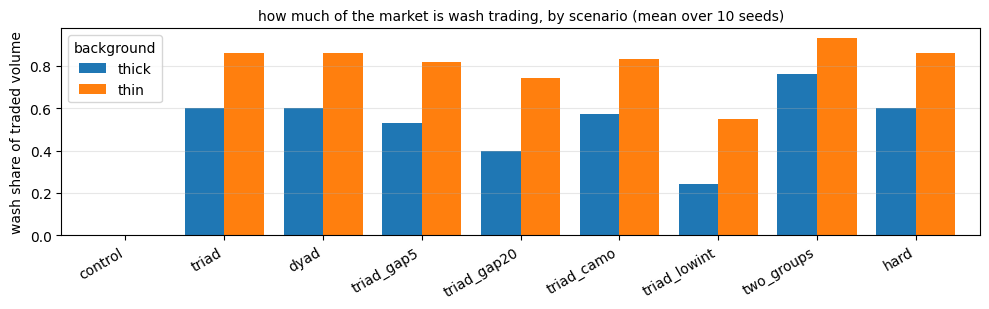

In [7]:
piv = overview["wash_volume_share"].unstack(0).reindex(order)
ax = piv.plot.bar(figsize=(10, 3.2), width=0.8)
ax.set_ylabel("wash share of traded volume"); ax.set_xlabel("")
ax.set_title("how much of the market is wash trading, by scenario (mean over 10 seeds)", fontsize=10)
ax.grid(axis="y", alpha=.3); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## E. The export schema: what a detector can see

Layout of one run:

```
runs/<background>__<scenario>__s<seed>/
  meta.json
  observable/   trades.csv (leg_id, time, wallet, side, qty, price)   lob.csv   lob_levels.csv
  labels/       wallets.csv  trade_legs.csv  wash_events.csv  wash_fills.csv  wash_orders.csv  lob_latent.csv
```

`observable/` mimics a public on-chain trade tape (the Polymarket setting): the account and side of every fill are
there, but **three leaks are closed on purpose**:

- **order ids are dropped** — wash orders use ids ≥ 1e9 and background orders ≤ 1e7, which would give the answer away;
- **wallets are anonymized** with a seeded permutation (`w000`, …) — raw agent ids put every wash wallet after the background agents;
- **legs are shuffled within each clear** before numbering — the matched-order list order comes from heap internals and depends on insertion order.

The batch auction itself does not record who traded with whom; reconstructing counterparties from `trades.csv`
is the detector's job (Part 2, see `detection/v1/pairing.py`).

In [8]:
rid = "thin__hard__s001"
rdir = os.path.join(DATA, "runs", rid)
for sub in ("observable", "labels"):
    files = sorted(os.listdir(os.path.join(rdir, sub)))
    print(sub + "/", ", ".join(f"{f} ({os.path.getsize(os.path.join(rdir, sub, f))/1024:.0f} KB)" for f in files))

obs, lab = load_observable(rdir), load_labels(rdir)
forbidden = {"order_id", "agent_id", "is_wash", "is_wash_leg", "group_id", "event_idx", "fundamental", "wash_legs", "wash_phase"}
print("\nleak columns present in observable/:", {k: sorted(forbidden & set(v.columns)) for k, v in obs.items()})
display(obs["trades"].head(6))
display(lab["wallets"].sort_values(["is_wash", "wallet"], ascending=[False, True]).head(8))

observable/ lob.csv (84 KB), lob_levels.csv (137 KB), trades.csv (13 KB)
labels/ lob_latent.csv (18 KB), trade_legs.csv (11 KB), wallets.csv (1 KB), wash_events.csv (31 KB), wash_fills.csv (21 KB), wash_orders.csv (21 KB)

leak columns present in observable/: {'trades': [], 'lob': [], 'lob_levels': []}


,leg_id,time,wallet,side,qty,price
0,0,19,w002,BUY,1,98396.410143
1,1,19,w000,SELL,1,98396.410143
2,2,26,w002,SELL,1,97466.921145
3,3,26,w000,BUY,1,97466.921145
4,4,27,w013,SELL,1,98616.047954
5,5,27,w014,BUY,1,98616.047954


,wallet,agent_id,behaviour,is_wash,group_id,camouflage,final_position,cash,n_legs,volume
0,w000,16,WashTrader+ZI,True,1,True,1,-100225.942559,85,85.0
2,w002,17,WashTrader+ZI,True,1,True,6,-603773.015714,80,80.0
10,w010,15,WashTrader+ZI,True,0,True,2,-196426.633218,46,46.0
13,w013,13,WashTrader+ZI,True,0,True,-3,297760.513616,45,45.0
14,w014,14,WashTrader+ZI,True,0,True,-1,102035.136201,43,43.0
1,w001,4,ZI,False,-1,False,-1,100775.429901,3,3.0
3,w003,1,ZI,False,-1,False,0,120.813875,4,4.0
4,w004,8,ZI,False,-1,False,-2,199511.630518,4,4.0


### Dataset size

LOB snapshots and top-5 depth levels dominate (≈56 MB of 76 MB). `data/` folders are git-ignored; regenerate with
`generate.py --name ds_v3 --seeds 10` (deterministic given the seeds).

In [9]:
sizes = {}
for dirpath, _, files in os.walk(os.path.join(DATA, "runs")):
    for f in files:
        key = os.path.join(os.path.basename(dirpath), f) if os.path.basename(dirpath) in ("observable", "labels") else f
        sizes[key] = sizes.get(key, 0) + os.path.getsize(os.path.join(dirpath, f))
pd.Series(sizes).div(2**20).round(1).sort_values(ascending=False).rename("MB over 180 runs").to_frame()

,MB over 180 runs
observable\lob_levels.csv,36.1
observable\lob.csv,20.2
labels\lob_latent.csv,3.8
labels\wash_events.csv,3.1
labels\wash_fills.csv,2.2
labels\wash_orders.csv,2.1
observable\trades.csv,1.7
labels\trade_legs.csv,1.4
meta.json,0.5
labels\wallets.csv,0.2


---
### Summary

- **v3 is a data generator fit for evaluating detectors**: camouflage wallets, multiple groups, the export schema
  (observable/labels split with three leaks closed), and a 180-run dataset from one command.
- **Regression guarantee**: without camouflage it matches v2 trade for trade; in camouflage runs a wallet's ZI arrival
  never cancelled its own resting wash leg (checked on every `order_book.remove` call in the smoke test).
- **A fact to keep in mind**: ZIs rarely trade in this market, so a camouflage wallet's ordinary trades are only
  ~4% (thin) / ~8% (thick) of its legs. Camouflage affects detection less by diluting volume than by
  **stopping the wallet's position from returning exactly to zero** (a weaker closing signal) — Part 2 shows the effect.
- Limitations: single asset; ZI is the only camouflage behaviour; the background is ZI-only (HBL is available but not
  in the scenarios).